In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [49]:
df.groupby("Bot Label").mean()

,User ID,Retweet Count,Mention Count,Follower Count,Verified,Tweet Frequency,Hashtag Count,Account Age,Engagement Ratio
Bot Label,,,,,,,,,
0,4991.565929,41.828646,4.463196,2573.436266,0.101735,4.997806,1.993816,1991.959705,0.033102
1,5007.475436,123.849609,21.992180,1014.370563,0.000000,29.448366,12.096050,182.819731,0.232986


In [50]:
selected_columns = [
    "Retweet Count",
    "Mention Count",
    "Follower Count",
    "Verified",
    "Tweet Frequency",
    "Hashtag Count",
    "Account Age",
    "Engagement Ratio",
    "Bot Label"
]

df = df[selected_columns]

In [51]:
from sklearn.preprocessing import StandardScaler

features = df.drop("Bot Label", axis=1)

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [52]:
import torch

X = torch.tensor(scaled_features, dtype=torch.float)

y = torch.tensor(df["Bot Label"].values, dtype=torch.long)

print(X.shape)
print(y.shape)

torch.Size([10000, 8])
torch.Size([10000])


In [53]:
from sklearn.neighbors import NearestNeighbors

k = 10

nbrs = NearestNeighbors(n_neighbors=k)

nbrs.fit(scaled_features)

distances, indices = nbrs.kneighbors(scaled_features)

In [54]:
edge_list = []

for i in range(len(indices)):
    for j in indices[i]:
        edge_list.append([i, j])

edge_index = torch.tensor(edge_list).t().contiguous()

print(edge_index.shape)

torch.Size([2, 100000])


In [55]:
from torch_geometric.data import Data

data = Data(
    x=X,
    edge_index=edge_index,
    y=y
)

print(data)

Data(x=[10000, 8], edge_index=[2, 100000], y=[10000])


In [56]:
num_nodes = data.num_nodes

perm = torch.randperm(num_nodes)

train_size = int(0.8 * num_nodes)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[perm[:train_size]] = True
test_mask[perm[train_size:]] = True

data.train_mask = train_mask
data.test_mask = test_mask

In [57]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch.nn import Linear

class GCN(torch.nn.Module):

    def __init__(self, in_channels):
        super().__init__()

        self.conv1 = GCNConv(in_channels, 32)
        self.conv2 = GCNConv(32, 32)

        self.classifier = Linear(32, 2)

    def forward(self, data):

        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)

        x = self.classifier(x)

        return x

In [58]:
model = GCN(in_channels=data.num_features)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.005
)

print(model)

GCN(
  (conv1): GCNConv(8, 32)
  (conv2): GCNConv(32, 32)
  (classifier): Linear(in_features=32, out_features=2, bias=True)
)


In [59]:
def train():

    model.train()

    optimizer.zero_grad()

    out = model(data)

    loss = F.cross_entropy(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()

    optimizer.step()

    return loss.item()

In [60]:
def test():

    model.eval()

    out = model(data)

    pred = out.argmax(dim=1)

    correct = (
        pred[data.test_mask]
        == data.y[data.test_mask]
    ).sum()

    acc = int(correct) / int(data.test_mask.sum())

    return acc

In [61]:
for epoch in range(1, 51):

    loss = train()

    acc = test()

    print(
        f"Epoch {epoch:02d}",
        f"Loss: {loss:.4f}",
        f"Accuracy: {acc:.4f}"
    )

Epoch 01 Loss: 0.6846 Accuracy: 0.8915
Epoch 02 Loss: 0.6436 Accuracy: 0.9580
Epoch 03 Loss: 0.6066 Accuracy: 0.9895
Epoch 04 Loss: 0.5649 Accuracy: 0.9970
Epoch 05 Loss: 0.5247 Accuracy: 1.0000
Epoch 06 Loss: 0.4835 Accuracy: 1.0000
Epoch 07 Loss: 0.4375 Accuracy: 1.0000
Epoch 08 Loss: 0.3931 Accuracy: 1.0000
Epoch 09 Loss: 0.3459 Accuracy: 1.0000
Epoch 10 Loss: 0.3007 Accuracy: 1.0000
Epoch 11 Loss: 0.2575 Accuracy: 1.0000
Epoch 12 Loss: 0.2141 Accuracy: 0.9995
Epoch 13 Loss: 0.1777 Accuracy: 0.9995
Epoch 14 Loss: 0.1440 Accuracy: 0.9990
Epoch 15 Loss: 0.1167 Accuracy: 0.9990
Epoch 16 Loss: 0.0932 Accuracy: 0.9990
Epoch 17 Loss: 0.0752 Accuracy: 0.9990
Epoch 18 Loss: 0.0592 Accuracy: 0.9990
Epoch 19 Loss: 0.0474 Accuracy: 0.9995
Epoch 20 Loss: 0.0373 Accuracy: 1.0000
Epoch 21 Loss: 0.0302 Accuracy: 1.0000
Epoch 22 Loss: 0.0241 Accuracy: 1.0000
Epoch 23 Loss: 0.0196 Accuracy: 1.0000
Epoch 24 Loss: 0.0159 Accuracy: 1.0000
Epoch 25 Loss: 0.0138 Accuracy: 1.0000
Epoch 26 Loss: 0.0115 Acc

In [62]:
final_acc = test()

print("Final Accuracy:", final_acc)

Final Accuracy: 1.0


In [63]:
model.eval()

with torch.no_grad():

    out = model(data)

    predictions = out.argmax(dim=1)

    probabilities = torch.softmax(out, dim=1)

    bot_prob = probabilities[:, 1]

In [64]:
df["Predicted Label"] = predictions.numpy()

df["Bot Probability"] = bot_prob.numpy()

df.head()

,Retweet Count,Mention Count,Follower Count,Verified,Tweet Frequency,Hashtag Count,Account Age,Engagement Ratio,Bot Label,Predicted Label,Bot Probability
0,75,2,3222,0,5,2,2769,0.023270,0,0,3.584640e-06
1,184,9,865,0,20,19,192,0.212471,1,1,9.999979e-01
2,73,6,1510,0,9,2,2505,0.048312,0,0,1.258808e-04
3,76,4,4600,0,6,1,836,0.016518,0,0,6.737062e-07
4,39,6,3040,1,6,3,2531,0.012825,0,0,2.275430e-10


In [65]:
df["Predicted Label"].value_counts()

,count
Predicted Label,
0,5019
1,4981


In [66]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_true = df["Bot Label"]
y_pred = df["Predicted Label"]

print("Accuracy:", accuracy_score(y_true, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Accuracy: 0.9994

Confusion Matrix:
[[5013    0]
 [   6 4981]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5013
           1       1.00      1.00      1.00      4987

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [67]:
top_bots = df.sort_values(
    "Bot Probability",
    ascending=False
).head(10)

top_bots

,Retweet Count,Mention Count,Follower Count,Verified,Tweet Frequency,Hashtag Count,Account Age,Engagement Ratio,Bot Label,Predicted Label,Bot Probability
9951,184,16,87,0,42,13,348,2.090909,1,1,1.0
9932,195,23,299,0,45,12,348,0.650000,1,1,1.0
9270,182,22,103,0,27,11,244,1.750000,1,1,1.0
9273,163,32,138,0,22,7,3,1.172662,1,1,1.0
1083,172,20,117,0,34,18,267,1.457627,1,1,1.0
9305,199,26,208,0,35,19,247,0.952153,1,1,1.0
1078,124,35,93,0,27,11,124,1.319149,1,1,1.0
9294,115,38,101,0,33,18,19,1.127451,1,1,1.0
5683,118,12,75,0,18,11,116,1.552632,1,1,1.0
5704,136,38,1502,0,45,13,136,0.090486,1,1,1.0


In [68]:
import networkx as nx

G = nx.Graph()

edges = edge_index.t().numpy()

G.add_edges_from(edges)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 10000
Edges: 65878


In [70]:
node_colors = [
    "red" if label == 1 else "green"
    for label in df["Predicted Label"]
]

In [71]:
print("Computing layout...")

pos = nx.spring_layout(
    G,
    k=0.12,
    iterations=15,
    seed=42
)

print("Layout ready")

Computing layout...
Layout ready


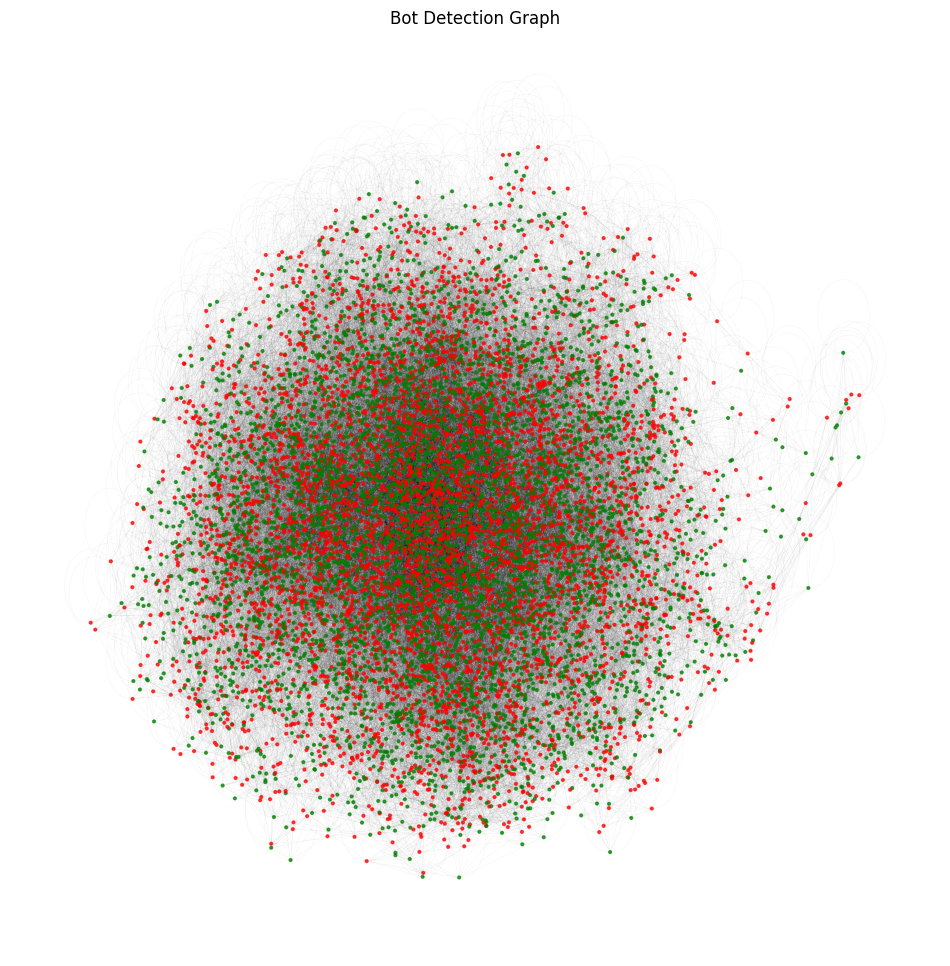

In [73]:
plt.figure(figsize=(12,12))

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=4,
    alpha=0.7
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.05,
    width=0.3
)

plt.title("Bot Detection Graph")

plt.axis("off")

plt.savefig(
    "full_bot_detection_graph.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

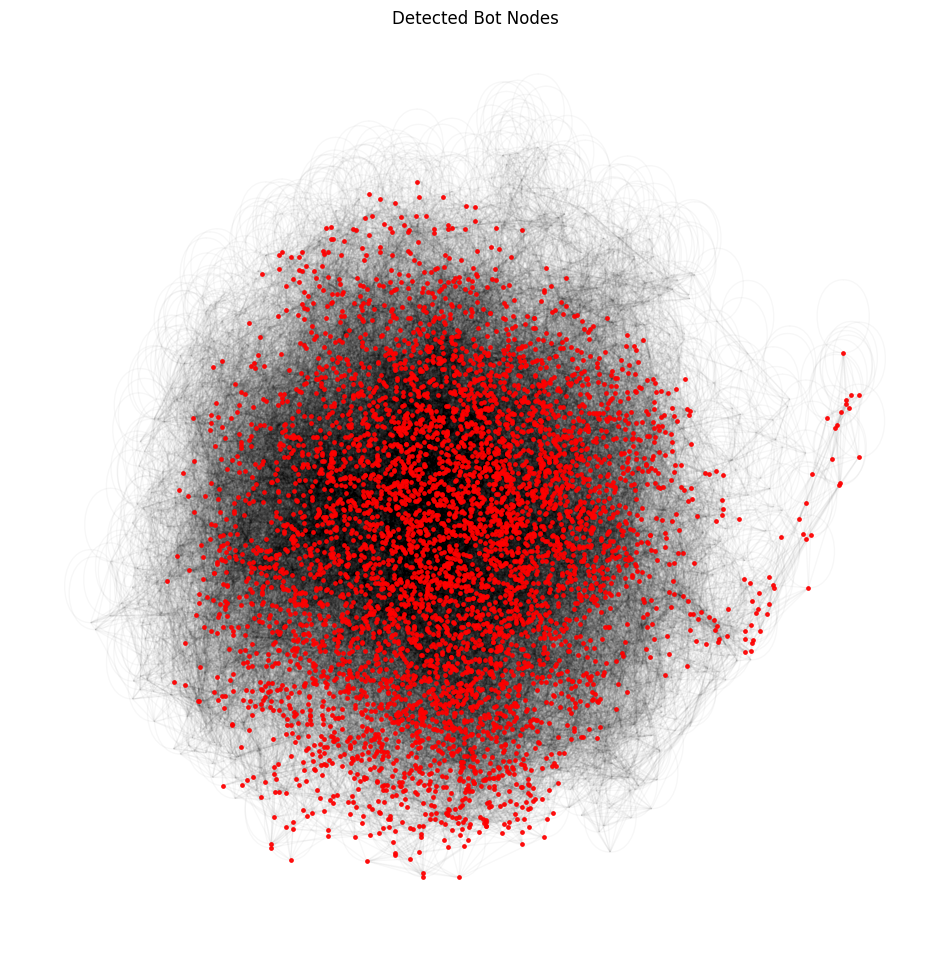

In [76]:
bot_nodes = df[df["Predicted Label"] == 1].index.tolist()

plt.figure(figsize=(12,12))

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=bot_nodes,
    node_color="red",
    node_size=6,
    alpha=0.9
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.03
)

plt.title("Detected Bot Nodes")

plt.axis("off")

plt.show()

In [77]:
df.to_csv(
    "bot_detection_results.csv",
    index=False
)

print("Results saved")

Results saved


In [78]:
import random

sample_nodes = random.sample(
    list(G.nodes()),
    500
)

G_small = G.subgraph(sample_nodes).copy()

print(
    "Nodes:", G_small.number_of_nodes(),
    "Edges:", G_small.number_of_edges()
)

Nodes: 500 Edges: 629


In [79]:
node_colors_small = [
    "red" if df.loc[node, "Predicted Label"] == 1
    else "green"
    for node in G_small.nodes()
]

In [80]:
import networkx as nx

print("Computing layout...")

pos_small = nx.spring_layout(
    G_small,
    k=0.3,
    iterations=50,
    seed=42
)

print("Layout ready")

Computing layout...
Layout ready


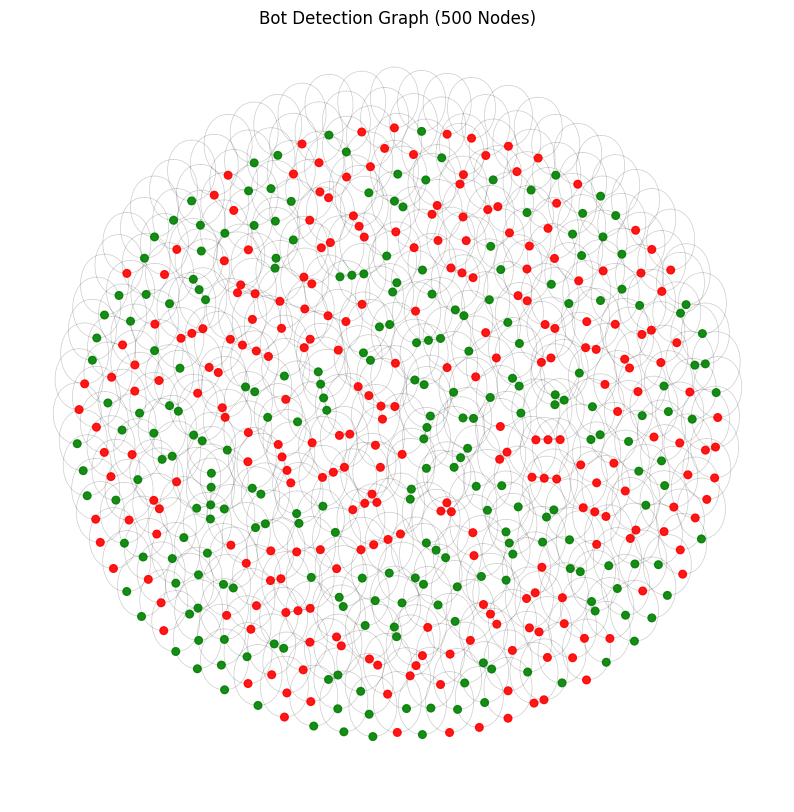

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

nx.draw_networkx_nodes(
    G_small,
    pos_small,
    node_color=node_colors_small,
    node_size=30,
    alpha=0.9
)

nx.draw_networkx_edges(
    G_small,
    pos_small,
    alpha=0.2,
    width=0.5
)

plt.title("Bot Detection Graph (500 Nodes)")

plt.axis("off")

plt.show()

In [82]:
bot_nodes = [
    node for node in G_small.nodes()
    if df.loc[node, "Predicted Label"] == 1
]

G_bots = G_small.subgraph(bot_nodes)

print(
    "Bot Nodes:",
    G_bots.number_of_nodes()
)

Bot Nodes: 258


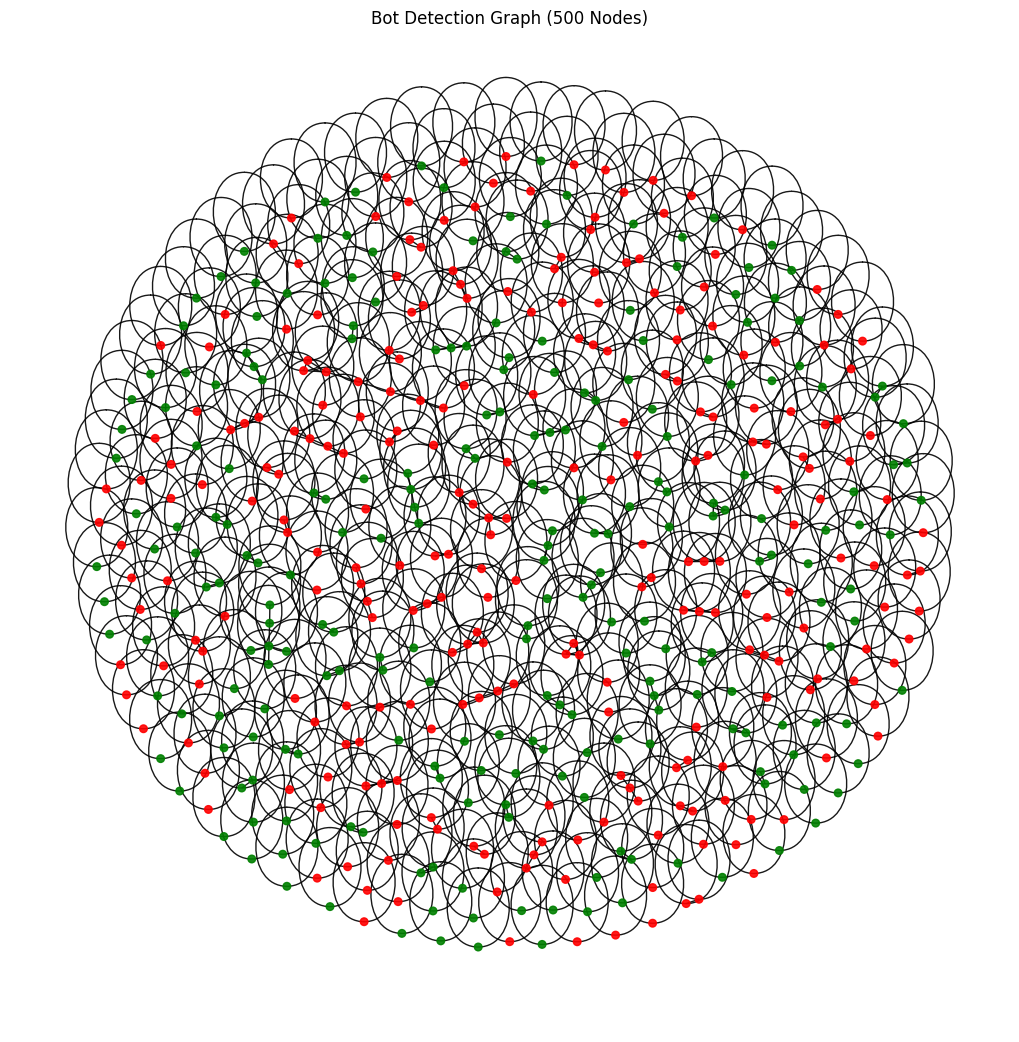

In [83]:
plt.figure(figsize=(10,10))

nx.draw(
    G_small,
    pos_small,
    node_color=node_colors_small,
    node_size=30,
    alpha=0.9
)

plt.title("Bot Detection Graph (500 Nodes)")

plt.axis("off")

plt.savefig(
    "bot_detection_graph_500_nodes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [84]:
import torch
import pickle

torch.save(
    model.state_dict(),
    "gnn_model.pth"
)

with open(
    "scaler.pkl",
    "wb"
) as f:
    pickle.dump(
        scaler,
        f
    )

print("Model and scaler saved")

Model and scaler saved
